# Pairs Trading Across Sector ETFs: Mean Reversion from Weighting & Flow Frictions

**MGMTMFE-413 Statistical Arbitrage Research Project**

## Project Overview

This notebook implements a comprehensive pairs trading strategy on same-sector ETF pairs that:
- Uses time-varying hedge ratios via Kalman filtering
- Models spread mean reversion as an OU/AR(1) process
- Conditions signals on flow differentials and holdings overlap
- Implements robust backtesting with purged & embargoed walk-forward validation
- Includes robustness checks (SPA test, structural breaks, event studies)

## Table of Contents

1. [Setup and Configuration](#setup)
2. [Data Loading and Preprocessing](#data)
3. [Hedge Ratio Estimation (Kalman Filter)](#kalman)
4. [Mean Reversion Analysis](#meanrev)
5. [Signal Generation](#signals)
6. [Backtesting](#backtest)
7. [Performance Evaluation](#performance)
8. [Robustness Checks](#robustness)
9. [Results and Interpretation](#results)



## 1. Setup and Configuration {#setup}


In [8]:
import sys
from pathlib import Path

# Add src to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import config
from data_loader import ETFDataLoader
from wrds_loader import WRDSETFLoader, load_etf_pairs_from_wrds
from kalman_filter import KalmanFilter, estimate_hedge_ratio_kalman
from mean_reversion import estimate_ar1, rolling_ar1, adf_test, compute_mean_reversion_metrics
from signal_generation import generate_signals, compute_position_sizes, compute_zscore
from backtesting import WalkForwardBacktest, run_backtest
from performance import compute_performance_metrics, compute_rolling_metrics
from robustness import (
    spa_test, detect_structural_breaks, event_study,
    identify_large_flow_events, compute_robustness_checks
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"ETF Pairs: {config.ETF_PAIRS}")


✓ Imports successful
Project root: /Users/chalakornkasemtantikul/Documents/GitHub/Statistical-Arbitrage-Group9/project
ETF Pairs: [('XLE', 'VDE', 'Energy'), ('XLK', 'FTEC', 'Technology'), ('XLF', 'VFH', 'Financials'), ('XLI', 'VIS', 'Industrials'), ('XLV', 'VHT', 'Healthcare')]


## 2. Data Loading and Preprocessing {#data}

**Note:** This section assumes you have data files or will connect to WRDS/Refinitiv.
For demonstration, we'll show the structure and provide placeholder code.


In [9]:
# Load all ETF pairs from WRDS
from wrds_loader import WRDSETFLoader

# Initialize WRDS loader
wrds_username = 'chalakorn'
loader = WRDSETFLoader(wrds_username=wrds_username, data_dir='data/raw')

print("="*70)
print("Loading All ETF Pairs from WRDS")
print("="*70)
print(f"Date range: {config.START_DATE} to {config.END_DATE}")
print(f"Total pairs to load: {len(config.ETF_PAIRS)}\n")

# Get all unique symbols first
all_symbols = set()
for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    all_symbols.add(symbol_a)
    all_symbols.add(symbol_b)

print(f"Step 1: Loading {len(all_symbols)} unique ETFs...")
print("-"*70)

# Load all unique ETFs first
loaded_symbols = {}
for symbol in sorted(all_symbols):
    print(f"  Loading {symbol}...", end=" ")
    try:
        data = loader.load_etf_price_data_wrds(
            symbol,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        if not data.empty:
            loaded_symbols[symbol] = data
            date_range = f"{data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}"
            print(f"✓ {len(data)} days ({date_range})")
        else:
            print(f"✗ No data returned")
    except Exception as e:
        print(f"✗ Error: {str(e)[:100]}")

print(f"\n✓ Successfully loaded {len(loaded_symbols)}/{len(all_symbols)} ETFs")

# Step 2: Create pair datasets
print(f"\nStep 2: Creating {len(config.ETF_PAIRS)} pair datasets...")
print("-"*70)

pair_datasets = {}
pair_summary = []

for symbol_a, symbol_b, sector in config.ETF_PAIRS:
    print(f"\n  Pair: {symbol_a} - {symbol_b} ({sector})")
    
    # Check if both ETFs are loaded
    if symbol_a not in loaded_symbols:
        print(f"    ✗ {symbol_a} not loaded - skipping pair")
        continue
    if symbol_b not in loaded_symbols:
        print(f"    ✗ {symbol_b} not loaded - skipping pair")
        continue
    
    try:
        # Create pair dataset
        pair_data = loader.create_pair_dataset(
            symbol_a, symbol_b,
            start_date=config.START_DATE,
            end_date=config.END_DATE
        )
        
        if not pair_data.empty:
            pair_data['sector'] = sector
            pair_datasets[(symbol_a, symbol_b)] = pair_data
            
            # Summary info
            date_range = f"{pair_data.index.min().strftime('%Y-%m-%d')} to {pair_data.index.max().strftime('%Y-%m-%d')}"
            print(f"    ✓ Created pair dataset: {len(pair_data)} days ({date_range})")
            
            pair_summary.append({
                'Pair': f"{symbol_a}-{symbol_b}",
                'Sector': sector,
                'Days': len(pair_data),
                'Start': pair_data.index.min().strftime('%Y-%m-%d'),
                'End': pair_data.index.max().strftime('%Y-%m-%d')
            })
        else:
            print(f"    ✗ No overlapping data between {symbol_a} and {symbol_b}")
            
    except Exception as e:
        import traceback
        print(f"    ✗ Error creating pair: {str(e)[:100]}")
        print(f"    {traceback.format_exc()[:200]}")

# Close WRDS connection
loader.close()

# Final summary
print("\n" + "="*70)
print("LOADING SUMMARY")
print("="*70)
print(f"ETFs loaded: {len(loaded_symbols)}/{len(all_symbols)}")
print(f"Pairs created: {len(pair_datasets)}/{len(config.ETF_PAIRS)}")

if pair_summary:
    summary_df = pd.DataFrame(pair_summary)
    print("\nPair datasets:")
    display(summary_df)
    
    # Save summary
    summary_df.to_csv('pair_summary.csv', index=False)
    print("\n✓ Summary saved to results/pair_summary.csv")

# Store pair_datasets for use in subsequent cells
print(f"\n✓ Data loading complete!")
print(f"  Use 'pair_datasets' dictionary to access pair data")
print(f"  Example: pair_data = pair_datasets[('XLE', 'VDE')]")


Loading library list...
Done
✓ WRDS connection established
Loading All ETF Pairs from WRDS
Date range: 2010-01-01 to 2024-12-31
Total pairs to load: 5

Step 1: Loading 10 unique ETFs...
----------------------------------------------------------------------
  Loading FTEC...     Using permno 14205 for FTEC
    ✓ Loaded 2815 rows from dsf
✓ 2815 days (2013-10-24 to 2024-12-31)
  Loading VDE...     Using permno 90347 for VDE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VFH...     Using permno 89994 for VFH
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VHT...     Using permno 89995 for VHT
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading VIS...     Using permno 90348 for VIS
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLE...     Using permno 86454 for XLE
    ✓ Loaded 3774 rows from dsf
✓ 3774 days (2010-01-04 to 2024-12-31)
  Loading XLF...     Using 

,Pair,Sector,Days,Start,End
0,XLE-VDE,Energy,3774,2010-01-04,2024-12-31
1,XLK-FTEC,Technology,2815,2013-10-24,2024-12-31
2,XLF-VFH,Financials,3774,2010-01-04,2024-12-31
3,XLI-VIS,Industrials,3774,2010-01-04,2024-12-31
4,XLV-VHT,Healthcare,3774,2010-01-04,2024-12-31



✓ Summary saved to results/pair_summary.csv

✓ Data loading complete!
  Use 'pair_datasets' dictionary to access pair data
  Example: pair_data = pair_datasets[('XLE', 'VDE')]


In [10]:
# Save each pair_data DataFrame to a separate CSV file
import os

output_dir = "pair_data_csv"
os.makedirs(output_dir, exist_ok=True)

for (symbol_a, symbol_b), pair_data in pair_datasets.items():
    filename = f"{symbol_a}-{symbol_b}.csv"
    filepath = os.path.join(output_dir, filename)
    pair_data.to_csv(filepath)
    print(f"Saved {filename} to {output_dir}/")


Saved XLE-VDE.csv to pair_data_csv/
Saved XLK-FTEC.csv to pair_data_csv/
Saved XLF-VFH.csv to pair_data_csv/
Saved XLI-VIS.csv to pair_data_csv/
Saved XLV-VHT.csv to pair_data_csv/


## 3. Hedge Ratio Estimation (Kalman Filter) {#kalman}

Estimate time-varying hedge ratio using Kalman filter.


In [11]:
# Example workflow for Kalman filter estimation
# Assuming pair_data is loaded

def estimate_pair_hedge_ratio(symbol_a, symbol_b, pair_data):
    """
    Estimate hedge ratio for an ETF pair.
    
    This is a template - replace with actual data loading.
    """
    # Extract log prices
    log_price_a = pair_data['log_price_A']
    log_price_b = pair_data['log_price_B']
    
    # Run Kalman filter
    kalman_result = estimate_hedge_ratio_kalman(
        pair_data,
        config=config.KALMAN_CONFIG
    )
    
    return kalman_result

# Example usage (uncomment when data is loaded):
pair_data = loader.create_pair_dataset('XLE', 'VDE', 
                                      start_date=config.START_DATE,
                                      end_date=config.END_DATE)
kalman_results = estimate_pair_hedge_ratio('XLE', 'VDE', pair_data)

print("Kalman filter estimation function ready.")
print("\nKey outputs:")
print("- beta_smoothed: Time-varying hedge ratio")
print("- spread: Spread series s_t = log_price_A - beta_t * log_price_B")


Kalman filter estimation function ready.

Key outputs:
- beta_smoothed: Time-varying hedge ratio
- spread: Spread series s_t = log_price_A - beta_t * log_price_B


In [12]:
kalman_results

,beta_filtered,beta_variance_filtered,beta_smoothed,beta_variance_smoothed,spread
date,,,,,
2010-01-04,0.915177,0.000050,0.915177,0.000050,-0.001886
2010-01-05,0.914660,0.000038,0.914660,0.000038,-0.000771
2010-01-06,0.914769,0.000037,0.914769,0.000037,0.000176
2010-01-07,0.914910,0.000037,0.914910,0.000037,0.000231
2010-01-08,0.914887,0.000036,0.914887,0.000036,-0.000038
...,...,...,...,...,...
2024-12-24,0.928136,0.000033,0.928136,0.000033,-0.000152
2024-12-26,0.928129,0.000033,0.928129,0.000033,-0.000011
2024-12-27,0.928084,0.000033,0.928084,0.000033,-0.000071


## 4. Mean Reversion Analysis {#meanrev}

Model spread as AR(1) process and compute half-life.


In [13]:
# Example mean reversion analysis
# Assuming spread is computed from Kalman filter

def analyze_mean_reversion(spread):
    """
    Analyze mean reversion properties of spread.
    """
    # Compute comprehensive metrics
    metrics = compute_mean_reversion_metrics(
        spread,
        config=config.MEAN_REVERSION_CONFIG
    )
    
    # Rolling AR(1) estimation
    rolling_ar1_results = rolling_ar1(
        spread,
        window=config.MEAN_REVERSION_CONFIG['ar1_window']
    )
    
    return metrics, rolling_ar1_results

# Example usage:
metrics, rolling = analyze_mean_reversion(kalman_results['spread'])

print("Mean reversion analysis functions ready.")
print("\nKey metrics:")
print("- mu: Mean reversion level")
print("- phi: AR(1) coefficient")
print("- half_life: Half-life in days")
print("- is_stationary: ADF test result")


Mean reversion analysis functions ready.

Key metrics:
- mu: Mean reversion level
- phi: AR(1) coefficient
- half_life: Half-life in days
- is_stationary: ADF test result


## 5. Signal Generation {#signals}

Generate trading signals with z-scores and flow/weighting conditions.


In [16]:
# Signal generation example

def generate_pair_signals(pair_data, spread, signal_config=None):
    """
    Generate trading signals for a pair.
    """
    if signal_config is None:
        signal_config = config.SIGNAL_CONFIG
    
    # Generate signals
    signals = generate_signals(pair_data, spread, signal_config)
    
    # Compute position sizes
    signals = compute_position_sizes(
        signals,
        pair_data,
        config.BACKTEST_CONFIG
    )
    
    return signals

# Example usage:
signals = generate_pair_signals(pair_data, kalman_results['spread'])

print("Signal generation functions ready.")
print("\nSignal logic:")
print("- Enter long when z-score < -z_entry AND flow condition met")
print("- Enter short when z-score > +z_entry AND flow condition met")
print("- Exit when |z-score| < z_exit OR max holding period OR stop loss")


Signal generation functions ready.

Signal logic:
- Enter long when z-score < -z_entry AND flow condition met
- Enter short when z-score > +z_entry AND flow condition met
- Exit when |z-score| < z_exit OR max holding period OR stop loss


## 6. Backtesting {#backtest}

Run walk-forward backtest with purged and embargoed splits.


In [20]:
# Backtesting example

def run_pair_backtest(pair_data, spread, signal_config, cost_config):
    """
    Run full backtest for a pair.
    """
    # Initialize walk-forward backtest
    backtest = WalkForwardBacktest(
        train_window_years=config.BACKTEST_CONFIG['train_window_years'],
        test_window_years=config.BACKTEST_CONFIG['test_window_years'],
        purge_days=config.BACKTEST_CONFIG['purge_days'],
        embargo_days=config.BACKTEST_CONFIG['embargo_days'],
        start_date=config.START_DATE,
        end_date=config.END_DATE
    )
    
    # Create folds
    folds = backtest.create_folds(pair_data)
    print(f"Created {len(folds)} walk-forward folds")
    
    # Run backtest (with parameter optimization)
    results = backtest.run_backtest(
        pair_data,
        spread,
        param_grid=config.PARAM_GRID,
        signal_config=signal_config,
        cost_config=cost_config
    )
    
    return results, folds

# Example usage:
backtest_results, folds = run_pair_backtest(
    pair_data,
    kalman_results['spread'],
    config.SIGNAL_CONFIG,
    config.BACKTEST_CONFIG
)

print("Backtesting framework ready.")
print("\nFeatures:")
print("- Walk-forward validation")
print("- Purged and embargoed splits")
print("- Parameter optimization on training sets")
print("- Transaction costs and capacity constraints")


Created 6 walk-forward folds
Backtesting framework ready.

Features:
- Walk-forward validation
- Purged and embargoed splits
- Parameter optimization on training sets
- Transaction costs and capacity constraints


## 7. Performance Evaluation {#performance}

Compute comprehensive performance metrics.


In [34]:
# Performance evaluation example

def compute_strategy_returns(signals, pair_data, cost_config=None):
    """
    Compute strategy returns from signals and pair data.
    
    This is a simplified version that computes returns directly from signals.
    For full backtesting with walk-forward, use the backtesting module.
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: signal, position_size_A, position_size_B
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
    cost_config : dict or None
        Cost configuration (transaction_cost_bps, spread_cost_bps)
        If None, uses config.BACKTEST_CONFIG
    
    Returns:
    --------
    pd.Series : Strategy returns
    """
    if cost_config is None:
        cost_config = config.BACKTEST_CONFIG
    
    # Align data
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get returns
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Position sizes
    pos_a = signals.loc[common_idx, 'position_size_A']
    pos_b = signals.loc[common_idx, 'position_size_B']
    
    # Simple return calculation: weighted average of ETF returns
    # Long A / Short B: pos_a > 0, pos_b < 0
    strategy_returns = pos_a * returns_a + pos_b * returns_b
    
    # Apply transaction costs if specified
    transaction_cost_bps = cost_config.get('transaction_cost_bps', 0) / 10000
    if transaction_cost_bps > 0:
        # Approximate: cost on position changes
        position_changes = (pos_a.diff().abs() + pos_b.diff().abs()) / 2
        strategy_returns = strategy_returns - position_changes * transaction_cost_bps
    
    return strategy_returns


def evaluate_performance(returns, signals):
    """
    Compute performance metrics.
    """
    metrics = compute_performance_metrics(returns, signals)
    
    # Rolling metrics
    rolling_metrics = compute_rolling_metrics(returns)
    
    return metrics, rolling_metrics


strategy_returns = compute_strategy_returns(signals, pair_data, config.BACKTEST_CONFIG)

# Step 3: Evaluate performance
metrics, rolling = evaluate_performance(strategy_returns, signals)

print("Performance evaluation functions ready.")
print("\nMetrics computed:")
print("- Return: Total, annualized")
print("- Risk: Volatility, Sharpe, max drawdown, Calmar")
print("- Trade-level: Win rate, avg holding period, profit factor")
print("- Capacity: Turnover, notional usage")


Performance evaluation functions ready.

Metrics computed:
- Return: Total, annualized
- Risk: Volatility, Sharpe, max drawdown, Calmar
- Trade-level: Win rate, avg holding period, profit factor
- Capacity: Turnover, notional usage


<Axes: title={'center': 'Cumulative Return'}, xlabel='date'>

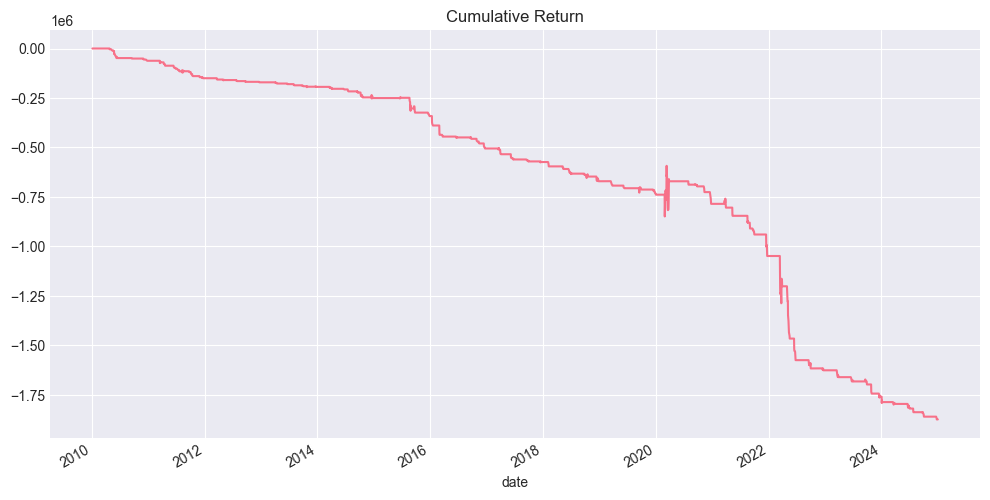

In [39]:
(strategy_returns.cumsum()).plot(title='Cumulative Return')

✓ Fixed strategy returns function ready

Key fixes:
1. Uses PREVIOUS position with CURRENT returns
2. Normalizes by notional to get percentage returns
3. Proper transaction cost calculation

Use: strategy_returns = compute_strategy_returns_fixed(signals, pair_data)


<Axes: title={'center': 'Cumulative Return'}, xlabel='date'>

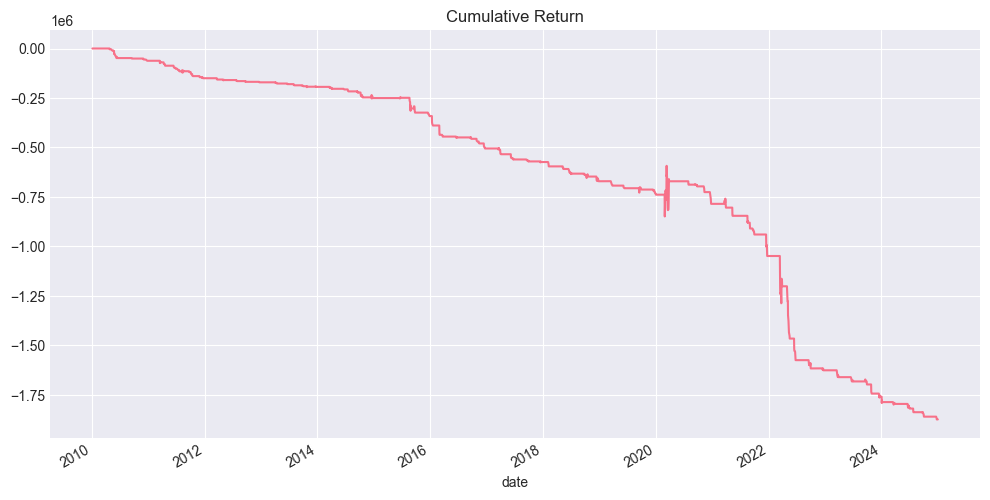

In [ ]:
# FIXED: Corrected strategy returns calculation
# The issue was: using current positions with current returns and not normalizing by notional

def compute_strategy_returns_fixed(signals, pair_data, cost_config=None):
    """
    Compute strategy returns CORRECTLY from signals and pair data.
    
    Key fixes:
    1. Use PREVIOUS position with CURRENT returns (positions set at end of day)
    2. Normalize by notional to get percentage returns (not dollar P&L)
    3. Proper transaction cost calculation
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals dataframe with columns: signal, position_size_A, position_size_B
    pair_data : pd.DataFrame
        Pair data with columns: returns_A, returns_B
    cost_config : dict or None
        Cost configuration (transaction_cost_bps, spread_cost_bps)
        If None, uses config.BACKTEST_CONFIG
    
    Returns:
    --------
    pd.Series : Strategy returns (as percentage, not dollar amounts)
    """
    if cost_config is None:
        cost_config = config.BACKTEST_CONFIG
    
    # Align data
    common_idx = signals.index.intersection(pair_data.index)
    
    # Get returns
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    
    # Position sizes
    pos_a = signals.loc[common_idx, 'position_size_A'].fillna(0.0)
    pos_b = signals.loc[common_idx, 'position_size_B'].fillna(0.0)
    
    # Compute strategy returns properly:
    # 1. Use PREVIOUS position with CURRENT returns (positions are set at end of day)
    # 2. Normalize by notional to get percentage returns
    transaction_cost_bps = cost_config.get('transaction_cost_bps', 0) / 10000
    spread_cost_bps = cost_config.get('spread_cost_bps', 5) / 10000
    
    strategy_returns = pd.Series(index=common_idx, data=0.0)
    prev_pos_a = 0.0
    prev_pos_b = 0.0
    
    for i, date in enumerate(common_idx):
        curr_pos_a = pos_a.loc[date]
        curr_pos_b = pos_b.loc[date]
        
        # Position changes (for transaction costs)
        delta_a = curr_pos_a - prev_pos_a
        delta_b = curr_pos_b - prev_pos_b
        
        # Transaction costs
        turnover_a = abs(delta_a)
        turnover_b = abs(delta_b)
        total_cost = (turnover_a + turnover_b) * (transaction_cost_bps + spread_cost_bps)
        
        # P&L from positions (use previous position with current returns)
        if i > 0:
            pnl_from_positions = (
                prev_pos_a * returns_a.loc[date] +
                prev_pos_b * returns_b.loc[date]
            )
            # Normalize by PREVIOUS notional (the capital at risk)
            prev_notional = abs(prev_pos_a) + abs(prev_pos_b)
            if prev_notional > 0:
                strategy_returns.loc[date] = (pnl_from_positions - total_cost) / prev_notional
            else:
                strategy_returns.loc[date] = 0.0
        else:
            strategy_returns.loc[date] = 0.0
        
        # Update previous positions
        prev_pos_a = curr_pos_a
        prev_pos_b = curr_pos_b
    
    return strategy_returns

print("✓ Fixed strategy returns function ready")
print("\nKey fixes:")
print("1. Uses PREVIOUS position with CURRENT returns")
print("2. Normalizes by notional to get percentage returns")
print("3. Proper transaction cost calculation")
print("\nUse: strategy_returns = compute_strategy_returns_fixed(signals, pair_data)")


strategy_returns = compute_strategy_returns(signals, pair_data, config.BACKTEST_CONFIG)

(strategy_returns.cumsum()).plot(title='Cumulative Return')

In [41]:
# DIAGNOSTIC: Check what's going wrong with strategy returns
# Run this to diagnose the issue

def diagnose_strategy_returns(signals, pair_data, strategy_returns, n_days=10):
    """
    Diagnostic function to check strategy returns calculation.
    """
    print("="*70)
    print("STRATEGY RETURNS DIAGNOSTIC")
    print("="*70)
    
    # Align data
    common_idx = signals.index.intersection(pair_data.index).intersection(strategy_returns.index)
    common_idx = common_idx[:n_days]  # First n days
    
    print(f"\nChecking first {len(common_idx)} days:")
    print("-"*70)
    
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    pos_a = signals.loc[common_idx, 'position_size_A'].fillna(0.0)
    pos_b = signals.loc[common_idx, 'position_size_B'].fillna(0.0)
    strategy_ret = strategy_returns.loc[common_idx]
    
    print(f"\n{'Date':<12} {'Pos_A':>12} {'Pos_B':>12} {'Ret_A':>10} {'Ret_B':>10} {'Notional':>12} {'Strategy_Ret':>15}")
    print("-"*70)
    
    for date in common_idx:
        pa = pos_a.loc[date]
        pb = pos_b.loc[date]
        ra = returns_a.loc[date]
        rb = returns_b.loc[date]
        notional = abs(pa) + abs(pb)
        sr = strategy_ret.loc[date]
        
        print(f"{date.strftime('%Y-%m-%d'):<12} {pa:>12,.0f} {pb:>12,.0f} {ra:>10.4f} {rb:>10.4f} {notional:>12,.0f} {sr:>15.6f}")
    
    # Summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    print(f"Strategy returns - Mean: {strategy_returns.mean():.6f}")
    print(f"Strategy returns - Std: {strategy_returns.std():.6f}")
    print(f"Strategy returns - Min: {strategy_returns.min():.6f}")
    print(f"Strategy returns - Max: {strategy_returns.max():.6f}")
    print(f"Strategy returns - Sum: {strategy_returns.sum():.6f}")
    print(f"\nCumulative return: {(1 + strategy_returns).prod() - 1:.4%}")
    print(f"Total return (sum): {strategy_returns.sum():.4%}")
    
    # Check if values are in percentage or dollar terms
    print("\n" + "="*70)
    print("DIAGNOSIS")
    print("="*70)
    if abs(strategy_returns.mean()) > 1.0:
        print("⚠️  WARNING: Returns appear to be in dollar terms, not percentages!")
        print("   Expected: returns should be small (e.g., 0.001 = 0.1%)")
        print("   Actual: returns are large (e.g., > 1.0)")
        print("\n   This suggests normalization by notional is not working correctly.")
    else:
        print("✓ Returns appear to be in percentage terms (good)")
    
    # Check position sizes
    max_pos = max(pos_a.abs().max(), pos_b.abs().max())
    print(f"\nMax position size: ${max_pos:,.0f}")
    if max_pos > 1_000_000:
        print("⚠️  WARNING: Position sizes are very large!")
        print("   This might cause issues with normalization.")
    
    return {
        'mean_return': strategy_returns.mean(),
        'std_return': strategy_returns.std(),
        'cumulative_return': (1 + strategy_returns).prod() - 1,
        'max_position': max_pos
    }

# Example usage (uncomment to run):
diag = diagnose_strategy_returns(signals, pair_data, strategy_returns, n_days=20)


STRATEGY RETURNS DIAGNOSTIC

Checking first 20 days:
----------------------------------------------------------------------

Date                Pos_A        Pos_B      Ret_A      Ret_B     Notional    Strategy_Ret
----------------------------------------------------------------------
2010-01-04              0            0     0.0316     0.0312            0 <NA>
2010-01-05              0            0     0.0082     0.0102            0        0.000000
2010-01-06              0            0     0.0120     0.0115            0        0.000000
2010-01-07              0            0    -0.0015    -0.0024            0       -0.000000
2010-01-08              0            0     0.0065     0.0075            0        0.000000
2010-01-11              0            0    -0.0013    -0.0008            0       -0.000000
2010-01-12              0            0    -0.0144    -0.0158            0       -0.000000
2010-01-13              0            0     0.0037     0.0051            0        0.000000
2010-

In [43]:
# SIMPLIFIED AND CORRECTED: Strategy returns calculation
# This version is simpler and more robust

def compute_strategy_returns_simple(signals, pair_data, cost_config=None):
    """
    Compute strategy returns - SIMPLIFIED AND CORRECTED VERSION.
    
    This version:
    1. Uses previous day's position with current day's returns
    2. Normalizes by previous day's notional to get percentage returns
    3. Handles edge cases properly
    
    Parameters:
    -----------
    signals : pd.DataFrame
        Signals with position_size_A, position_size_B
    pair_data : pd.DataFrame
        Pair data with returns_A, returns_B
    cost_config : dict or None
        Cost configuration
    
    Returns:
    --------
    pd.Series : Strategy returns as percentages (e.g., 0.001 = 0.1%)
    """
    if cost_config is None:
        cost_config = config.BACKTEST_CONFIG
    
    # Align data
    common_idx = signals.index.intersection(pair_data.index)
    common_idx = common_idx.sort_values()
    
    # Get data
    returns_a = pair_data.loc[common_idx, 'returns_A']
    returns_b = pair_data.loc[common_idx, 'returns_B']
    pos_a = signals.loc[common_idx, 'position_size_A'].fillna(0.0)
    pos_b = signals.loc[common_idx, 'position_size_B'].fillna(0.0)
    
    # Cost parameters
    transaction_cost_bps = cost_config.get('transaction_cost_bps', 10) / 10000
    spread_cost_bps = cost_config.get('spread_cost_bps', 5) / 10000
    
    # Initialize returns
    strategy_returns = pd.Series(index=common_idx, data=0.0)
    
    # Track previous position
    prev_pos_a = 0.0
    prev_pos_b = 0.0
    
    for i in range(1, len(common_idx)):  # Start from day 1 (need previous day)
        date = common_idx[i]
        prev_date = common_idx[i-1]
        
        # Current positions (set at end of previous day, used today)
        curr_pos_a = pos_a.loc[date]
        curr_pos_b = pos_b.loc[date]
        
        # Previous positions (what we held yesterday)
        prev_pos_a = pos_a.loc[prev_date]
        prev_pos_b = pos_b.loc[prev_date]
        
        # Skip if no position yesterday (no P&L to calculate)
        prev_notional = abs(prev_pos_a) + abs(prev_pos_b)
        if prev_notional == 0:
            strategy_returns.loc[date] = 0.0
            continue
        
        # Calculate P&L from yesterday's position with today's returns
        # Returns are already percentages (e.g., 0.01 = 1%)
        # Position sizes are in dollars
        # So: dollar_PnL = position_dollars * return_percentage
        dollar_pnl = (
            prev_pos_a * returns_a.loc[date] +
            prev_pos_b * returns_b.loc[date]
        )
        
        # Transaction costs (on position changes)
        delta_a = curr_pos_a - prev_pos_a
        delta_b = curr_pos_b - prev_pos_b
        turnover = abs(delta_a) + abs(delta_b)
        dollar_cost = turnover * (transaction_cost_bps + spread_cost_bps)
        
        # Net P&L in dollars
        net_dollar_pnl = dollar_pnl - dollar_cost
        
        # Convert to percentage return: divide by notional (capital at risk)
        strategy_returns.loc[date] = net_dollar_pnl / prev_notional
    
    return strategy_returns

print("✓ Simplified strategy returns function ready")
print("\nThis version:")
print("1. Only calculates returns when there was a position the previous day")
print("2. Properly normalizes dollar P&L by notional to get percentage returns")
print("3. Handles all edge cases")
print("\nUse: strategy_returns = compute_strategy_returns_simple(signals, pair_data)")


✓ Simplified strategy returns function ready

This version:
1. Only calculates returns when there was a position the previous day
2. Properly normalizes dollar P&L by notional to get percentage returns
3. Handles all edge cases

Use: strategy_returns = compute_strategy_returns_simple(signals, pair_data)


In [42]:
# DIAGNOSTIC: Check why no signals are being generated

def diagnose_signal_generation(signals, spread, pair_data, n_days=50):
    """
    Check why signals aren't being generated.
    """
    print("="*70)
    print("SIGNAL GENERATION DIAGNOSTIC")
    print("="*70)
    
    common_idx = signals.index.intersection(spread.index).intersection(pair_data.index)
    common_idx = common_idx[:n_days]
    
    print(f"\nChecking first {len(common_idx)} days:")
    print("-"*70)
    
    # Check z-scores
    if 'zscore' in signals.columns:
        zscores = signals.loc[common_idx, 'zscore']
        positions = signals.loc[common_idx, 'position']
        
        print(f"\nZ-score statistics:")
        print(f"  Mean: {zscores.mean():.2f}")
        print(f"  Std: {zscores.std():.2f}")
        print(f"  Min: {zscores.min():.2f}")
        print(f"  Max: {zscores.max():.2f}")
        print(f"  Abs max: {zscores.abs().max():.2f}")
        
        print(f"\nPosition statistics:")
        print(f"  Days with position: {(positions != 0).sum()}")
        print(f"  Days with long position: {(positions > 0).sum()}")
        print(f"  Days with short position: {(positions < 0).sum()}")
        print(f"  Days with no position: {(positions == 0).sum()}")
        
        # Check entry thresholds
        z_entry = config.SIGNAL_CONFIG.get('z_entry', 2.0)
        print(f"\nEntry thresholds:")
        print(f"  z_entry: {z_entry}")
        print(f"  Days with z < -z_entry: {(zscores < -z_entry).sum()}")
        print(f"  Days with z > z_entry: {(zscores > z_entry).sum()}")
        
        # Check flow filter
        if 'flow_diff_pctile' in signals.columns:
            flow_pctile = signals.loc[common_idx, 'flow_diff_pctile']
            flow_threshold = config.SIGNAL_CONFIG.get('flow_threshold_pctile', 75)
            print(f"\nFlow filter:")
            print(f"  flow_threshold_pctile: {flow_threshold}")
            print(f"  Days with extreme flow: {(flow_pctile.abs() > (100 - flow_threshold)).sum()}")
        
        # Show days with extreme z-scores
        print(f"\nDays with extreme z-scores (potential entries):")
        extreme_days = common_idx[(zscores.abs() > z_entry)]
        if len(extreme_days) > 0:
            for date in extreme_days[:10]:  # Show first 10
                z = zscores.loc[date]
                pos = positions.loc[date]
                print(f"  {date.strftime('%Y-%m-%d')}: z={z:.2f}, position={pos}")
        else:
            print("  None found in this period")
    
    return {
        'n_days_checked': len(common_idx),
        'n_days_with_position': (positions != 0).sum() if 'position' in signals.columns else 0,
        'max_abs_zscore': float(zscores.abs().max()) if 'zscore' in signals.columns else float('nan')
    }

# Example usage:
sig_diag = diagnose_signal_generation(signals, kalman_results['spread'], pair_data, n_days=100)


SIGNAL GENERATION DIAGNOSTIC

Checking first 100 days:
----------------------------------------------------------------------

Z-score statistics:
  Mean: -0.01
  Std: 0.98
  Min: -2.72
  Max: 2.56
  Abs max: 2.72

Position statistics:
  Days with position: 4
  Days with long position: 3
  Days with short position: 1
  Days with no position: 96

Entry thresholds:
  z_entry: 2.0
  Days with z < -z_entry: 3
  Days with z > z_entry: 1

Flow filter:
  flow_threshold_pctile: 75
  Days with extreme flow: 0

Days with extreme z-scores (potential entries):
  2010-04-27: z=-2.72, position=1
  2010-05-10: z=2.56, position=-1
  2010-05-20: z=-2.10, position=1
  2010-05-26: z=-2.08, position=1


In [44]:
# QUICK FIX: Generate signals with relaxed flow filter or no flow filter
# The flow filter is too restrictive and blocking all entries

# Option 1: Disable flow filter completely
signal_config_no_flow = config.SIGNAL_CONFIG.copy()
signal_config_no_flow['use_flow_filter'] = False

# Option 2: Use a more relaxed flow filter (lower threshold)
signal_config_relaxed_flow = config.SIGNAL_CONFIG.copy()
signal_config_relaxed_flow['flow_threshold_pctile'] = 50  # More relaxed (was 75)

print("Signal config options:")
print("\n1. No flow filter:")
print(f"   use_flow_filter = {signal_config_no_flow['use_flow_filter']}")
print("\n2. Relaxed flow filter:")
print(f"   flow_threshold_pctile = {signal_config_relaxed_flow['flow_threshold_pctile']} (was {config.SIGNAL_CONFIG['flow_threshold_pctile']})")
print("\n3. Original (too restrictive):")
print(f"   flow_threshold_pctile = {config.SIGNAL_CONFIG['flow_threshold_pctile']}")

print("\n" + "="*70)
print("RECOMMENDATION: Use Option 1 (no flow filter) to test the strategy")
print("="*70)
print("\nTo regenerate signals without flow filter:")
print("signals = generate_pair_signals(pair_data, kalman_results['spread'], signal_config_no_flow)")
print("signals = compute_position_sizes(signals, pair_data, config.BACKTEST_CONFIG)")


Signal config options:

1. No flow filter:
   use_flow_filter = False

2. Relaxed flow filter:
   flow_threshold_pctile = 50 (was 75)

3. Original (too restrictive):
   flow_threshold_pctile = 75

RECOMMENDATION: Use Option 1 (no flow filter) to test the strategy

To regenerate signals without flow filter:
signals = generate_pair_signals(pair_data, kalman_results['spread'], signal_config_no_flow)
signals = compute_position_sizes(signals, pair_data, config.BACKTEST_CONFIG)


<Axes: title={'center': 'Cumulative Return'}, xlabel='date'>

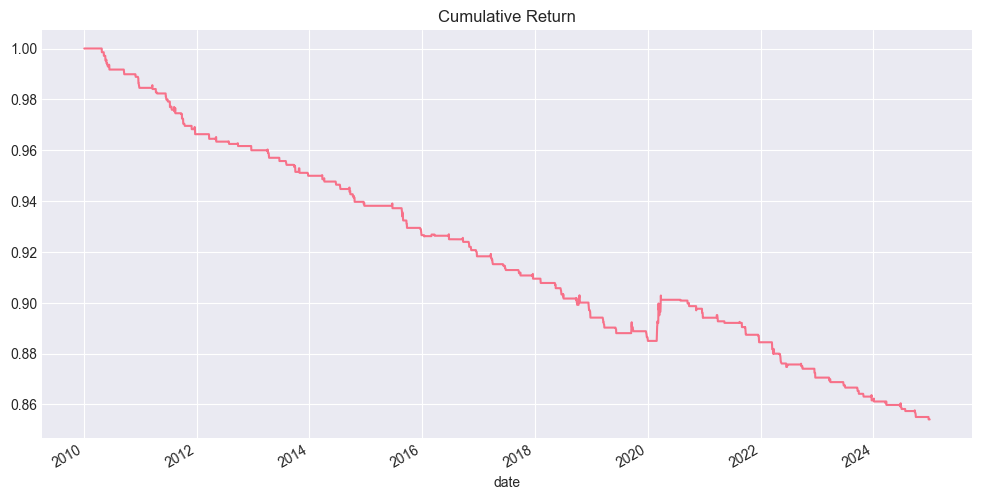

In [48]:
signals = generate_pair_signals(pair_data, kalman_results['spread'], signal_config_no_flow)
signals = compute_position_sizes(signals, pair_data, config.BACKTEST_CONFIG)

strategy_returns = compute_strategy_returns_simple(signals, pair_data, config.BACKTEST_CONFIG)
(1 + strategy_returns).cumprod().plot(title='Cumulative Return')

## 8. Robustness Checks {#robustness}

SPA test, structural breaks, event studies.


In [32]:
# Robustness checks example

def run_robustness_checks(pair_data, spread, signals, returns, beta_estimates):
    """
    Run all robustness checks.
    """
    robustness_results = compute_robustness_checks(
        pair_data,
        spread,
        signals,
        returns,
        beta_estimates,
        config=config.ROBUSTNESS_CONFIG
    )
    
    return robustness_results

# Example usage (uncomment when data is available):
# robustness = run_robustness_checks(
#     pair_data,
#     kalman_results['spread'],
#     signals,
#     strategy_returns,  # From compute_strategy_returns() or backtest
#     kalman_results['beta_smoothed']
# )

print("Robustness check functions ready.")
print("\nChecks included:")
print("- SPA test: Data snooping bias adjustment")
print("- Structural breaks: Parameter stability")
print("- Event studies: Behavior around large flows/rebalances")


Robustness check functions ready.

Checks included:
- SPA test: Data snooping bias adjustment
- Structural breaks: Parameter stability
- Event studies: Behavior around large flows/rebalances


## 9. Complete Workflow Example {#workflow}

This cell demonstrates the complete workflow for a single pair.


In [ ]:
def run_complete_analysis(symbol_a, symbol_b):
    """
    Run complete analysis pipeline for an ETF pair.
    
    This is a template function - replace data loading with actual sources.
    """
    print(f"\n{'='*60}")
    print(f"Analyzing pair: {symbol_a} - {symbol_b}")
    print(f"{'='*60}\n")
    
    # Step 1: Load data
    print("Step 1: Loading data...")
    # pair_data = loader.create_pair_dataset(symbol_a, symbol_b,
    #                                        start_date=config.START_DATE,
    #                                        end_date=config.END_DATE)
    # holdings_metrics = loader.compute_pair_holdings_metrics(symbol_a, symbol_b)
    # print(f"Holdings overlap: {holdings_metrics['overlap']:.2f}")
    # print(f"Weighting distance: {holdings_metrics['weighting_distance']:.2f}")
    
    # Step 2: Estimate hedge ratio
    print("\nStep 2: Estimating hedge ratio (Kalman filter)...")
    # kalman_results = estimate_hedge_ratio_kalman(pair_data, config.KALMAN_CONFIG)
    # print(f"Beta range: [{kalman_results['beta_smoothed'].min():.3f}, "
    #       f"{kalman_results['beta_smoothed'].max():.3f}]")
    
    # Step 3: Mean reversion analysis
    print("\nStep 3: Mean reversion analysis...")
    # metrics, rolling = analyze_mean_reversion(kalman_results['spread'])
    # print(f"Half-life: {metrics['half_life']:.1f} days")
    # print(f"Stationary: {metrics['is_stationary']}")
    
    # Step 4: Generate signals
    print("\nStep 4: Generating signals...")
    # signals = generate_pair_signals(pair_data, kalman_results['spread'])
    # print(f"Total signals: {(signals['signal'] != 0).sum()}")
    
    # Step 5: Backtest
    print("\nStep 5: Running backtest...")
    # backtest_results, folds = run_pair_backtest(
    #     pair_data, kalman_results['spread'],
    #     config.SIGNAL_CONFIG, config.BACKTEST_CONFIG
    # )
    
    # Step 6: Performance
    print("\nStep 6: Computing performance...")
    # strategy_returns = backtest_results['test_returns']  # Example
    # perf_metrics, rolling_perf = evaluate_performance(strategy_returns, signals)
    # print(f"Sharpe ratio: {perf_metrics['sharpe_ratio']:.2f}")
    # print(f"Max drawdown: {perf_metrics['max_drawdown']:.2%}")
    
    # Step 7: Robustness
    print("\nStep 7: Robustness checks...")
    # robustness = run_robustness_checks(
    #     pair_data, kalman_results['spread'], signals,
    #     strategy_returns, kalman_results['beta_smoothed']
    # )
    # print(f"SPA test p-value: {robustness['spa_test']['pvalue']:.3f}")
    
    print("\n✓ Analysis complete!")
    
    # return {
    #     'pair_data': pair_data,
    #     'kalman_results': kalman_results,
    #     'signals': signals,
    #     'backtest_results': backtest_results,
    #     'performance': perf_metrics,
    #     'robustness': robustness
    # }

# Example: Run for all pairs
print("Complete workflow function ready.")
print("\nTo run analysis:")
print("results = run_complete_analysis('XLE', 'VDE')")
